# PhotoGraphiQ tutorials

This notebook merges every tutorial script in `examples/tutorials` with its page in `docs/tutorials`.
Each section is self-contained (it re-imports what it needs), so you can run any one on its own; running top-to-bottom executes the whole series.

- **Part I (01–08)** Gaussian MBQC
- **Part II (09–16)** nonlinear experiments
- **Part III (17–24)** structure, extensibility and the experimental v0.3 paths
- **Part IV (37–49)** encoded GKP logic

Install the [required extras](../../docs/getting-started/installation.md) first. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).
Figures are shown inline; to export one, call `plt.gcf().savefig("experiment.svg")` before `plt.show()`.

**About the checks.** The assertions in the script check the stated example property. They complement
the independent [validation suites](../../docs/validation/index.md); they do not certify
arbitrary parameter regimes. For Fock experiments, repeat at larger cutoff before
using a numerical result in a publication. Keep selected measurement branches
fixed when comparing conditional states.

Graph connectivity and the temporal command DAG describe different aspects of
the experiment; a graph picture alone is not a gate-equivalence certificate.

In [1]:
!rm -rf PhotoGraphiQ

!git clone \
    --branch manuscript-experiments \
    --single-branch \
    https://github.com/chinmoybiswasdeep/PhotoGraphiQ.git

%cd /content/PhotoGraphiQ

%pip install -e ".[dev,autodiff,visualization,validation,docs]"

Cloning into 'PhotoGraphiQ'...
remote: Enumerating objects: 1501, done.
remote: Counting objects: 100% (1501/1501), done.
remote: Compressing objects: 100% (920/920), done.
remote: Total 1501 (delta 638), reused 1408 (delta 549), pack-reused 0 (from 0)
Receiving objects: 100% (1501/1501), 26.61 MiB | 18.61 MiB/s, done.
Resolving deltas: 100% (638/638), done.
/content/PhotoGraphiQ
Obtaining file:///content/PhotoGraphiQ
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pathspec-1.1.1-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 

In [24]:
A=5

# Part I — Gaussian MBQC

Input labels identify injected states; preparation commands introduce ancillas.
Inspect those boundaries before changing a measurement or correction.

## 01. Your first CV cluster state

**Goal.** Build a three-mode resource and inspect its nullifier noise. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** For a graph adjacency A, ideal nullifiers are p-Aq. Finite momentum squeezing gives residual variance exp(-2r). A resource without measurements has no classical outcomes. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

In [15]:
!python -c "import photographiq as pg; print(pg.__version__)"

0.3.1


Output modes: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)
Nullifier covariance: [[0.049787 0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.      ]
 [0.       0.049787 0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.      ]
 [0.       0.       0.049787 0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.049787 0.       0.       0.       0.
  0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.049787 0.       0.       0.
  0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.049787 0.       0.
  0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.       0.049787 0.
  0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.       0.       0.049787
  0.       0.       0.       0.    

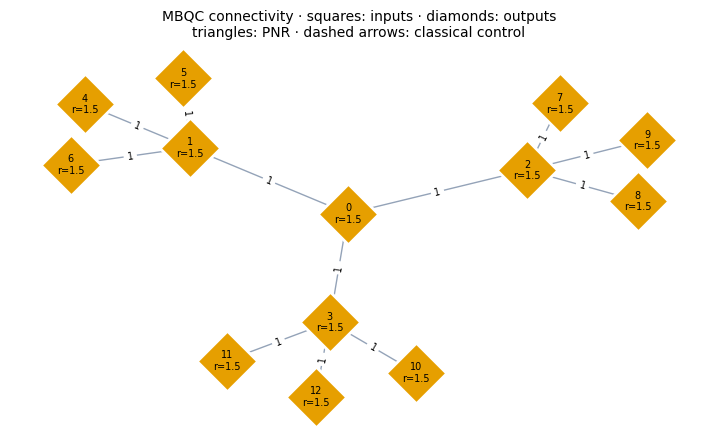

In [38]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

no_of_modes, squeezing = 3,1.5
graph = pg.CVGraph.tree(no_of_modes, squeezing=squeezing, height=2)
pattern = pg.Pattern(graph)
result = pg.simulate(pattern, backend="gaussian", seed=7)
nullifiers = graph.nullifiers()
noise = nullifiers @ result.state.covariance @ nullifiers.T
print("Output modes:", result.state.nodes)
print("Nullifier covariance:", np.round(noise, 6))

pattern.draw()
plt.show()

**Interpretation.** The diagonal entries are residual nullifier variances. Their nonzero values reflect finite squeezing, not a failed entangling operation.

**Things to try.** Change squeezing to 0.4 and 1.0. Predict the variance ratio before running. Then replace the line with a ring.

## 02. CV quantum teleportation

**Goal.** Compare the optical teleportation channel with its analytical added noise. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** The Braunstein–Kimble protocol uses an entangled two-mode resource and two quadrature measurements. Its unconditional covariance adds 2 exp(-2r) I. A selected trajectory differs from this average channel. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Unconditional output mean: [0.6 0.2]
Added noise: [[ 0.403793 -0.      ]
 [-0.        0.403793]]
Conditional outcomes: {0: 0.4259093188015401, 1: 0.5409740781537619}


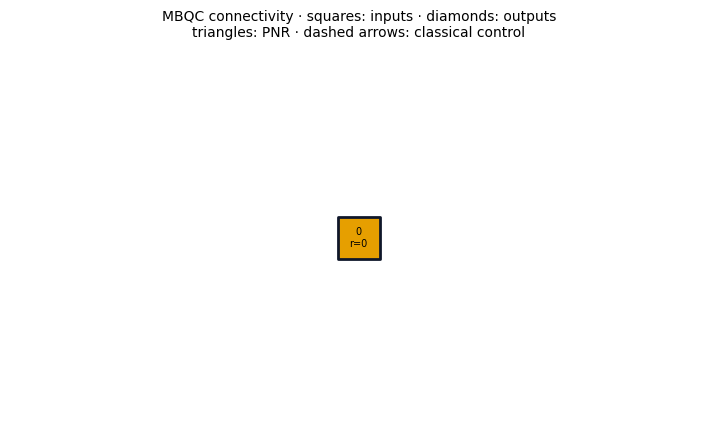

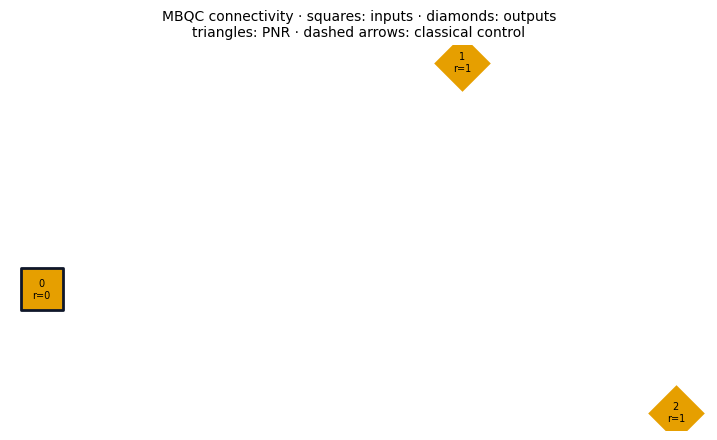

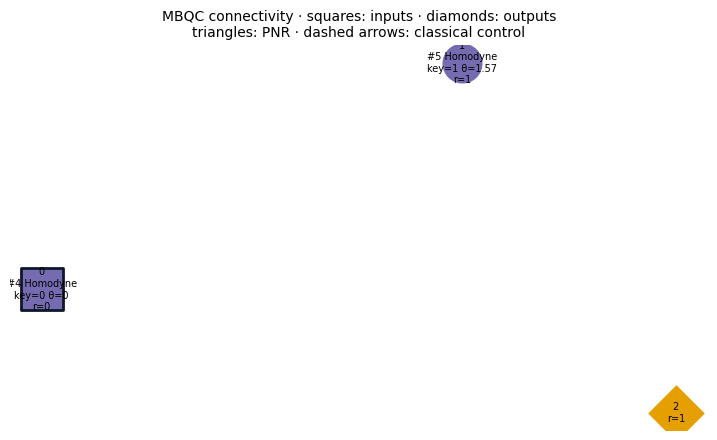

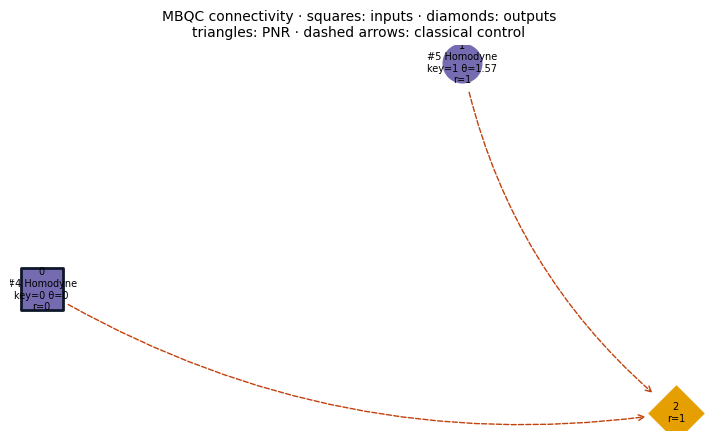

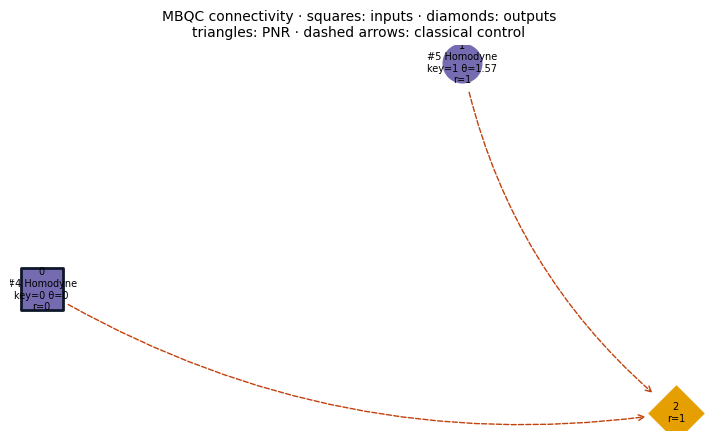

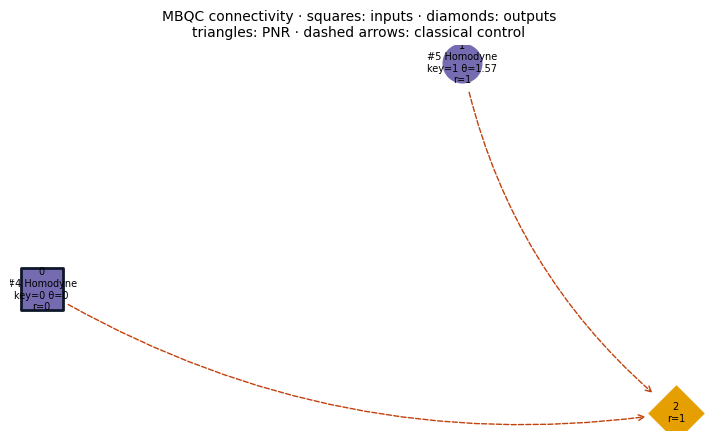

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

pattern = pg.protocols.teleportation(squeezing=0.8)
channel = pg.gaussian_channel(pattern)
initial = pg.GaussianInput.coherent(0.3 + 0.1j).state(0)
output = channel.apply(initial)
print("Unconditional output mean:", np.round(output.mean, 6))
print("Added noise:", np.round(channel.noise, 6))
np.testing.assert_allclose(channel.noise, 2 * np.exp(-1.6) * np.eye(2), atol=1e-12)
print(
    "Conditional outcomes:",
    pg.simulate(pattern, inputs={0: pg.GaussianInput.coherent(0.3 + 0.1j)}, seed=7).outcomes,
)
pattern.draw()
plt.show()

**Interpretation.** The channel preserves the coherent displacement and adds noise. The sampled outcomes are real measurement readings, not probabilities or target amplitudes.

**Things to try.** Sweep r and compute overlap with a pure coherent target relabelled to the output. Compare channel moments with a large shot ensemble.

In [2]:
## Need another tutorial combining 1 and 2

## 03. One-dimensional quantum wire

**Goal.** Distinguish one Fourier teleportation step from four-step identity transport. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Each p measurement in a canonical CZ wire implements a Fourier step. Four such steps compose to identity on first moments, with accumulated finite-resource noise. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

One-step map: [[-0.2 -1. ]
 [ 1.   0. ]]
Four-step map: [[ 1. -0.]
 [ 0.  1.]]
Accumulated noise: [[0.403793 0.      ]
 [0.       0.403793]]


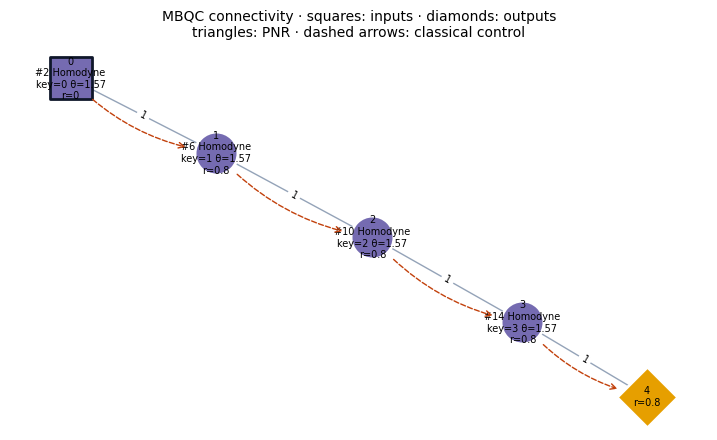

In [4]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

one = pg.protocols.wire([0.2], squeezing=0.8)
four = pg.protocols.identity(squeezing=0.8)
print("One-step map:", np.round(pg.gaussian_channel(one).matrix, 6))
channel = pg.gaussian_channel(four)
print("Four-step map:", np.round(channel.matrix, 6))
print("Accumulated noise:", np.round(channel.noise, 6))
np.testing.assert_allclose(channel.matrix, np.eye(2), atol=1e-12)
four.draw()
plt.show()

**Interpretation.** Identity refers to the ideal linear transformation. It does not mean the finite-squeezing output covariance equals the input covariance.

**Things to try.** Compare lengths 4, 8 and 12. Keep squeezing fixed to isolate accumulated noise.

## 04. Adaptive homodyne measurement

**Goal.** Run a measurement whose angle depends on an earlier result. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Outcome expressions carry explicit dependencies. The scheduler rejects future references. Adaptive trajectories can remain Gaussian individually while their ensemble is non-Gaussian. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Outcomes: {0: 0.002765848743238239, 1: 0.6764225459043837}
Records: {0: 0.002765848743238239, 1: 0.6764225459043837}
Output q moments: (-0.16530337711343948, 0.9721985205139547)


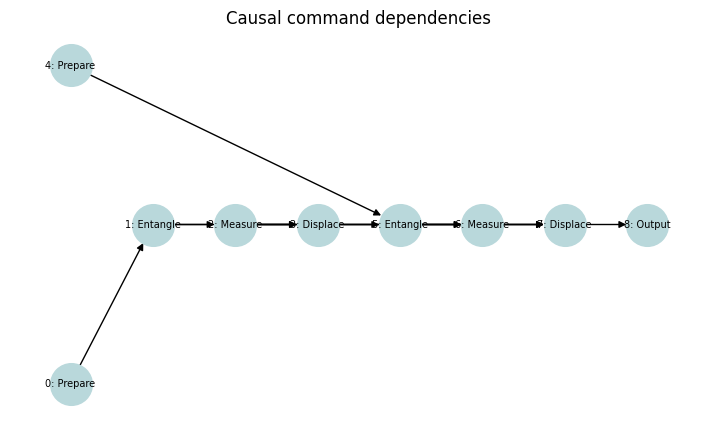

In [14]:
import matplotlib.pyplot as plt

import photographiq as pg

pattern = pg.protocols.adaptive(squeezing=0.7)
result = pg.simulate(pattern, parameters={"k": 0.2}, seed=7, backend="piquasso")
print("Outcomes:", result.outcomes)
print("Records:", result.records)
print("Output q moments:", result.state.quadrature(pattern.outputs[0]))
assert len(result.outcomes) == 2
from photographiq.visualization import draw_dependencies  # noqa: E402

draw_dependencies(pattern)
plt.show()

**Interpretation.** The first reading influences the second measurement setting. Equal input states need not produce equal settings on different trajectories.

**Things to try.** Change k and the seed independently. Inspect the dependency DAG to identify which angle can be chosen before measurement.

## 05. Classical feed-forward

**Goal.** Create a named signal and use it for a displacement. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** A Signal writes a derived classical register. Outcomes contains physical measurement readings; records additionally contains computed signals. Displacement parameters are q/p translations. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Measurements: {'m': 0.002765848743238239}
All records: {'m': 0.002765848743238239, 'correction': -0.002765848743238239}
Executed displacements: 1


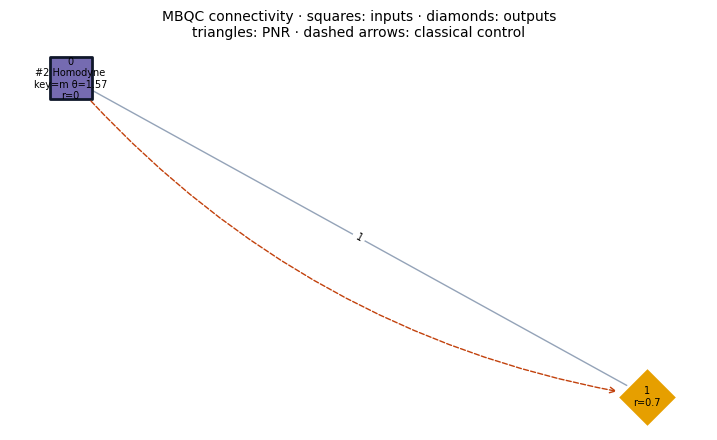

In [17]:
import matplotlib.pyplot as plt

import photographiq as pg

pattern = pg.Pattern(pg.CVGraph.line(2, squeezing=0.7, inputs=(0,)))
pattern.measure(0, pg.Homodyne.p(), key="m")
pattern.append(pg.Signal("correction", -pg.Outcome("m")))
pattern.displace(1, q=pg.Outcome("correction"))
result = pg.simulate(pattern, seed=7, backend="gaussian")
print("Measurements:", result.outcomes)
print("All records:", result.records)
print("Executed displacements:", result.physical_displacements)
assert result.records["correction"] == -result.outcomes["m"]
pattern.draw()
plt.show()

**Interpretation.** The correction record is computed, not independently sampled. Its negative sign cancels the measured displacement in this wire convention.

**Things to try.** Compare frame=False and frame=True using the same seed. Verify output moments, then compare physical displacement counts.

## 06. Finite squeezing and noise

**Goal.** Separate resource noise from numerical accuracy. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Increasing finite resource squeezing reduces wire noise exponentially. This is a physical change, unlike increasing Fock cutoff for a fixed experiment. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

r=0.4, noise trace=1.797316
r=0.5, noise trace=1.471518
r=0.6, noise trace=1.204777
r=0.7, noise trace=0.986388
r=0.8, noise trace=0.807586
r=0.9, noise trace=0.661196
r=1.0, noise trace=0.541341
r=1.1, noise trace=0.443213
r=1.2, noise trace=0.362872


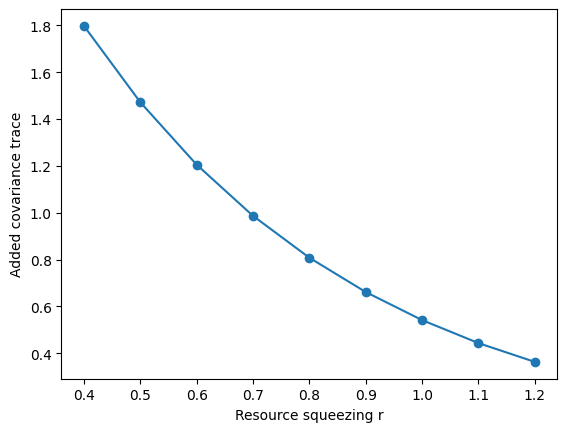

In [22]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

r_vals = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
values = []
for r in r_vals:
    channel = pg.gaussian_channel(pg.protocols.identity(squeezing=r))
    values.append(float(np.trace(channel.noise)))
    print(f"r={r:.1f}, noise trace={values[-1]:.6f}")
assert values[0] > values[1] > values[2]
plt.plot(r_vals, values, marker="o")
plt.xlabel("Resource squeezing r")
plt.ylabel("Added covariance trace")
plt.show()

**Interpretation.** The declining curve quantifies the physical finite-squeezing contribution. It is not a backend error estimate.

**Things to try.** Add a Loss command and study whether increasing resource squeezing removes the resulting channel noise.

## 07. Gaussian gate compilation

**Goal.** Compile a rotation and squeeze, then inspect the exact affine channel. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Compilation expresses the target symplectic map through homodyne teleportation gadgets. The channel analyzer separates its ideal matrix from finite-resource noise. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg
# .rotate(0, 0.3)
circuit = pg.Circuit(3).squeeze(0, 0.2).rotate(1,0.4).squeeze(2,0.3).cz(1,2).cz(0,2)#.kerr(0,0.3)
pattern, trace = circuit.compile(squeezing=0.8, return_trace=True)
channel = pg.gaussian_channel(pattern)
print("Linear map:", np.round(channel.matrix, 6))
print("Added noise:", np.round(channel.noise, 6))
print("Generated measurements:", [step.measurements for step in trace.steps])
# assert len(trace.steps) == 2
pg.visualize_compilation(circuit, pattern, trace=trace)
plt.show()

/content/PhotoGraphiQ/src/photographiq/compiler.py:147: UserWarning: Kerr compilation is approximate: cubic commutator synthesis has leading amplitude error O(steps**-0.5), before finite-resource and cutoff errors. Verify all three limits.
  return compile_circuit(


NotImplementedError: Non-Gaussian preparation

/content/PhotoGraphiQ/src/photographiq/compiler.py:147: UserWarning: Kerr compilation is approximate: cubic commutator synthesis has leading amplitude error O(steps**-0.5), before finite-resource and cutoff errors. Verify all three limits.
  return compile_circuit(


Physical nodes: 581
Commands: 2489
Synthesis report: SynthesisReport(method='Lie product formula with cubic commutators', steps=1, primitive_count=182, warning='Refine synthesis steps, resource squeezing and cutoff independently.', approximate=True, order=0.5, target_gate='Kerr', target_parameter=0.0001)


/content/PhotoGraphiQ/src/photographiq/backends/fock.py:465: RuntimeWarning: GaussianTransform: retained Fock norm 0.99999996; test a larger cutoff
  self._gate((u, v), pq.GaussianTransform(passive=passive, active=active))
/content/PhotoGraphiQ/src/photographiq/backends/fock.py:465: RuntimeWarning: GaussianTransform: retained Fock norm 0.99999667; test a larger cutoff
  self._gate((u, v), pq.GaussianTransform(passive=passive, active=active))
/content/PhotoGraphiQ/src/photographiq/backends/fock.py:465: RuntimeWarning: GaussianTransform: retained Fock norm 0.99999539; test a larger cutoff
  self._gate((u, v), pq.GaussianTransform(passive=passive, active=active))


ValueError: Fock truncation norm 1.0087189; increase cutoff=100

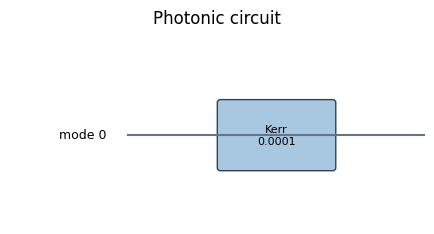

In [69]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg
# .rotate(0, 0.3)
# .squeeze(0, 0.2).rotate(1,0.4).squeeze(2,0.3).cz(1,2).cz(0,2)
circuit = pg.Circuit(1).kerr(0,1e-4)
circuit.draw()

pattern, trace = circuit.compile(squeezing=0.2,synthesis_steps=1,return_trace=True)

print("Physical nodes:", len(pattern.graph.nodes))
print("Commands:", len(pattern.commands))
print("Synthesis report:", trace.steps[0].synthesis_report)

result = pg.simulate(pattern, inputs={0: pg.GaussianInput.coherent(1.0)}, backend="piquasso-fock", cutoff=100, seed=7)

print("Actual output nodes:", result.state.nodes)

output_node = result.state.nodes[0]

result.state.wigner(np.linspace(-4, 4, 81), np.linspace(-4, 4, 81), node = output_node).plot()

# small_pattern.draw(labels=False,dependencies=False)
plt.show()

**Interpretation.** The output linear map is the composed gate action. Noise is separately nonzero, and trace indices show the measurement cost of each gate.

**Things to try.** Reverse the gate order and predict which matrix changes. Compare resource counts for identity and a generic rotation.

## 08. Two-mode entangling computation

**Goal.** Compile a logical CZ gate and inspect cross-mode correlations. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** A logical CZ transforms both momenta using the other mode position. Compilation includes transport steps after entanglement, unlike a single physical Entangle command. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Logical CZ map: [[ 1.  -0.  -0.   0. ]
 [ 0.   1.   0.4  0. ]
 [-0.   0.   1.  -0. ]
 [ 0.4  0.   0.   1. ]]
Covariance: [[ 1.404 -0.    -0.     0.4  ]
 [-0.     1.564  0.4    0.   ]
 [-0.     0.4    1.404 -0.   ]
 [ 0.4    0.    -0.     1.564]]
Output labels: (5, 9)
Added Noise: [[0.403793 0.       0.       0.      ]
 [0.       0.403793 0.       0.      ]
 [0.       0.       0.403793 0.      ]
 [0.       0.       0.       0.403793]]


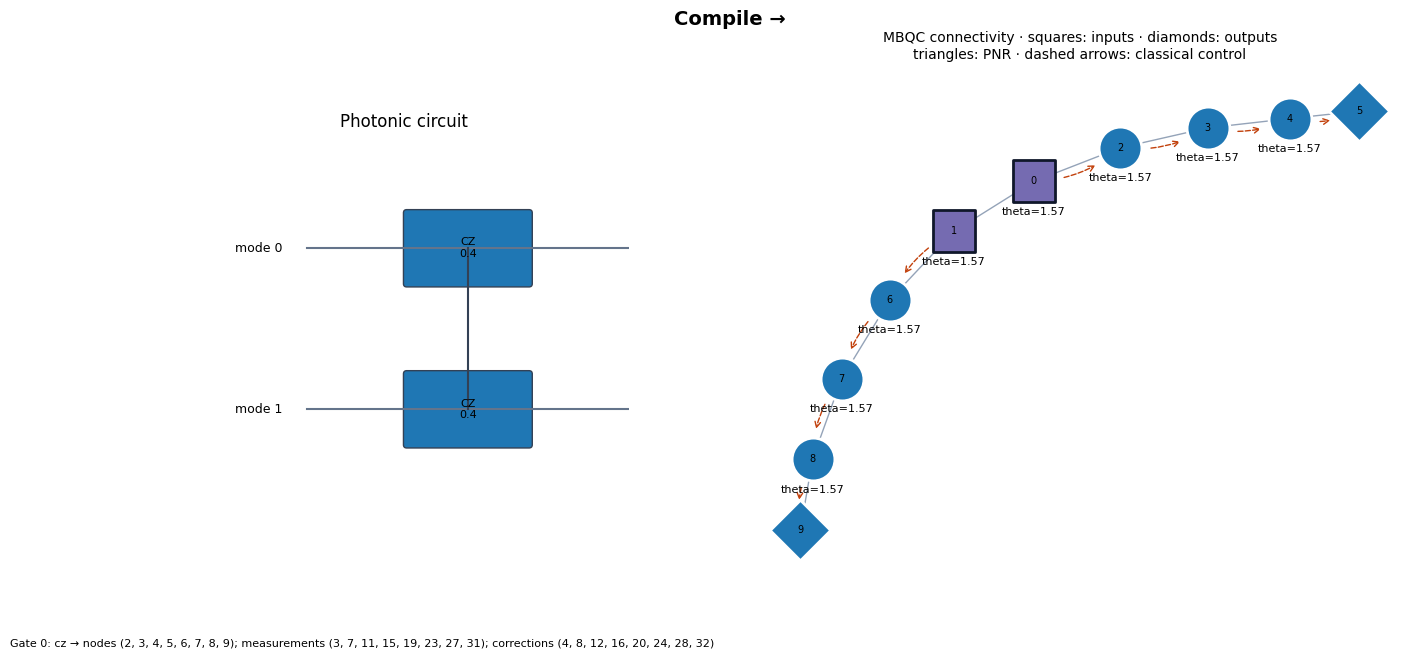

In [11]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

circuit = pg.Circuit(2).cz(0, 1, 0.4)
pattern = circuit.compile(squeezing=0.8)
channel = pg.gaussian_channel(pattern)

input_state = pg.GaussianState(np.zeros(4), np.eye(4), (0, 1))
output_state = channel.apply(input_state)

## V_out = X @ V_in @ X.T + Y
X = channel.matrix; print("Logical CZ map:", np.round(X, 3))
V_out = output_state.covariance; print("Covariance:", np.round(V_out, 3))
V_in = input_state.covariance

Y = V_out - X @ V_in @ X.T
Y[np.abs(Y) < 1e-12] = 0.0 # Remove insignificant numerical roundoff

print("Output labels:", output_state.nodes)
print("Added Noise:", np.round(Y, 6))
assert abs(output_state.covariance[0, 3]) > 0
pg.visualize_compilation(circuit, pattern)
plt.show()


# result = pg.simulate(pattern, backend="piquasso-fock", cutoff=100, seed=0)
# axis = np.linspace(-4, 4, 51)
# nodes = result.state.nodes
# fig, axes = plt.subplots(1,len(nodes),figsize=(5 * len(nodes), 4),constrained_layout=True)
# if len(nodes) == 1:
#     axes = [axes]
# for ax, node in zip(axes, nodes):
#     grid = result.state.wigner(axis,axis,node=node)
#     ax, artist = grid.plot(ax=ax)
#     ax.set_title(f"Reduced Wigner: node {node}")
#     fig.colorbar(artist, ax=ax, label=r"$W(q,p)$")
# pg.visualize_compilation(circuit, pattern)
# plt.show()


**Interpretation.** Nonzero cross blocks record correlations. Their presence alone is not a complete entanglement witness for arbitrary mixed states.

**Things to try.** Change CZ weight sign and inspect which correlations change sign. Compare physical and logical CZ resource counts.

# Part II — Nonlinear experiments

## 09. Photon-number measurement

**Goal.** Select one branch of a correlated two-mode Fock resource. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Destructive PNR projects one mode onto a number state. The branch probability follows Born’s rule and the remaining mode is normalized conditionally. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Branch probability: 0.5000000000000001
Remaining photon number: 1.0


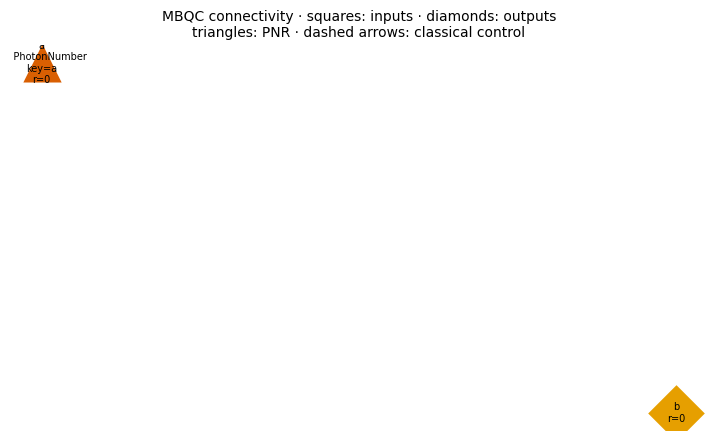

In [50]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

resource = pg.FockSuperposition.from_mapping({(0, 0): 2**-0.5, (1, 1): 2**-0.5})
pattern = (
    pg.Pattern().append(pg.PrepareResource(("a", "b"), resource)).measure("a", pg.PhotonNumber())
)
result = pg.simulate(pattern, backend="piquasso-fock", cutoff=6, measurement_outcomes={"a": 1})
print("Branch probability:", np.exp(result.log_likelihood))
print("Remaining photon number:", result.state.photon_number("b"))
# assert np.isclose(np.exp(result.log_likelihood), 0.5)
# assert np.isclose(result.state.photon_number("b"), 1)
pattern.draw()
plt.show()

**Interpretation.** The probability is one half; the remaining state has one photon given the selected count. Postselection does not make the branch occur on every experimental shot.

**Things to try.** Remove postselection, repeat many shots, and compare empirical count frequencies with one half.

## 10. Kerr nonlinearity

**Goal.** Observe number-dependent phase without changing photon probabilities. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Kerr applies exp(i kappa n²). Diagonal phases preserve the photon distribution while changing phase-sensitive observables and the Wigner function. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Photon number: 0.5000000000000002
q moments: (0.8253356149096784, 1.3188211227616629)


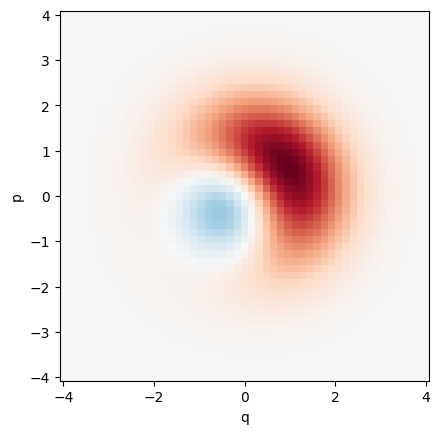

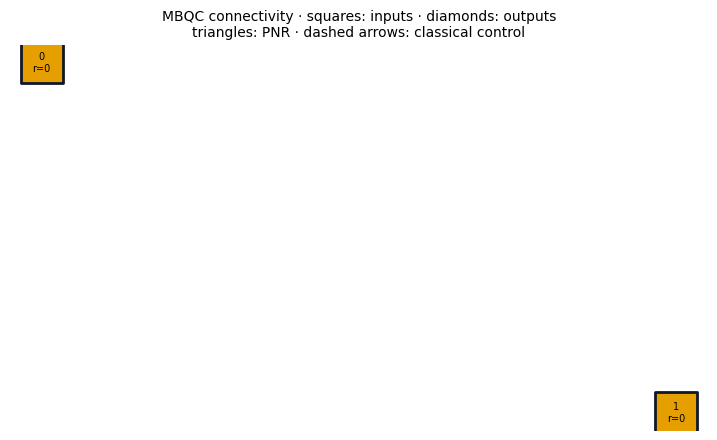

In [70]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

initial = pg.FockInput((2**-0.5, 2**-0.5))
pattern = pg.Pattern(inputs=(0,1,)).append(pg.Kerr(0, 0.6))#.append(pg.Squeeze(0,0.5)).append(pg.Rotate(0,0.6)).append(pg.Entangle(0,1,0.3))
result = pg.simulate(pattern, inputs={0: initial}, backend="piquasso-fock", cutoff=20)
print("Photon number:", result.state.photon_number(0))
print("q moments:", result.state.quadrature(0))
# assert np.isclose(result.state.photon_number(0), 0.5)
# assert np.isclose(result.state.quadrature(0)[0], np.cos(0.3))
result.state.wigner(np.linspace(-4, 4, 51), np.linspace(-4, 4, 51), node=0).plot()

pattern.draw()
plt.show()

**Interpretation.** Unchanged photon number does not mean unchanged state. The q mean detects the relative phase between vacuum and one-photon amplitudes.

**Things to try.** Include a two-photon component to expose the n² phase. Compare with ordinary rotation.

## 11. Cubic-phase gate

**Goal.** Check the first momentum moment after a weak cubic phase on vacuum. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** At hbar=2, CP(gamma)=exp(i gamma q³/6) sends p to p+gamma q². On vacuum the expected p mean is gamma. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Momentum mean and variance: 1.2958127064056857 4.747554943544136
Minimum retained norm: 0.9999999999999879


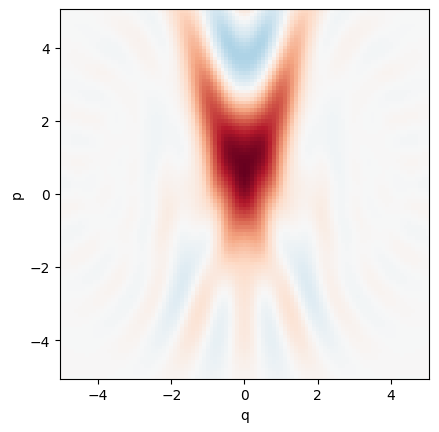

In [80]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

pattern = pg.Pattern(inputs=(0,)).append(pg.CubicPhase(0, 1.5))
result = pg.simulate(pattern, backend="piquasso-fock", cutoff=24)
mean, variance = result.state.quadrature(0, np.pi / 2)
print("Momentum mean and variance:", mean, variance)
print("Minimum retained norm:", min(result.state.retained_norms))
# assert abs(mean - 0.03) < 1e-5
result.state.wigner(np.linspace(-5, 5, 101), np.linspace(-5, 5, 101)).plot()
plt.show()

**Interpretation.** The momentum mean follows the nonlinear shear. A retained norm near one is useful but does not certify convergence of fourth moments.

**Things to try.** Increase gamma and compare cutoffs. Monitor p⁴ as well as mean p.

## 12. Cat-state resource

**Goal.** Prepare an even cat and inspect parity. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** An even cat combines coherent amplitudes +alpha and -alpha. Only even photon occupations remain in the ideal normalized superposition. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Parity: 1.0000000000000002
Photon number: 2.2005587581452586


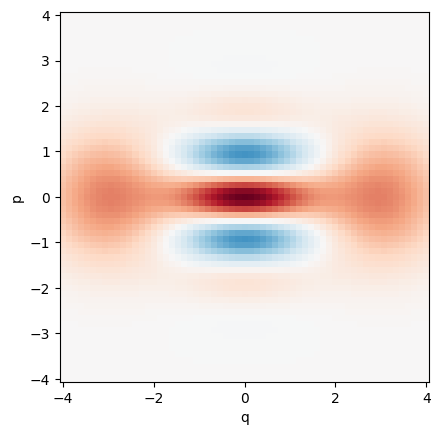

In [95]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

pattern = pg.Pattern(inputs=(0,))
result = pg.simulate(
    pattern, inputs={0: pg.CatResource(1.5, 1)}, backend="piquasso-fock", cutoff=20
)
print("Parity:", result.state.parity())
print("Photon number:", result.state.photon_number(0))
# assert np.isclose(result.state.parity(), 1.0)
result.state.wigner(np.linspace(-4, 4, 61), np.linspace(-4, 4, 61)).plot()
plt.show()

**Interpretation.** Parity +1 reflects support on even occupations. Wigner interference depends on alpha and phase-space resolution.

**Things to try.** Switch to odd parity, then use a complex alpha. Explain the rotated interference pattern.

## 13. Heralded photon subtraction

**Goal.** Compare a physical one-photon tap probability with its analytical value. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** A vacuum beamsplitter tap followed by one detected photon implements an attenuated subtraction Kraus map. It approaches ideal subtraction only in the weak-tap limit. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Herald probability: 0.07582332266320865
Conditional photon number: 1.0


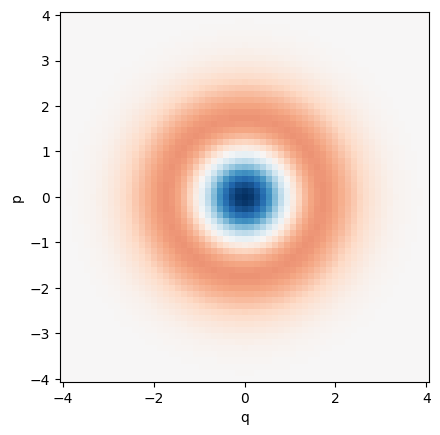

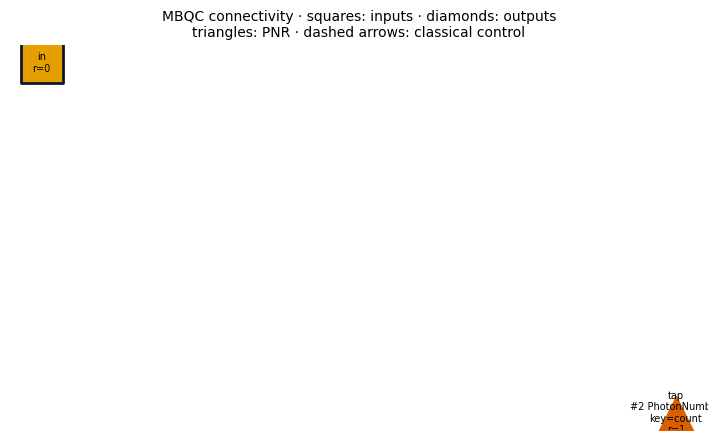

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

theta = 0.2
pattern = pg.non_gaussian.photon_subtraction(theta=theta)
result = pg.simulate(
    pattern,
    inputs={"in": pg.FockInput.number(2)},
    backend="piquasso-fock",
    cutoff=6,
    measurement_outcomes={"count": 1},
)

result.state.wigner(np.linspace(-4, 4, 61), np.linspace(-4, 4, 61)).plot()

probability = np.exp(result.log_likelihood)
print("Herald probability:", probability)
print("Conditional photon number:", result.state.photon_number("in"))
assert np.isclose(probability, 2 * np.sin(theta) ** 2 * np.cos(theta) ** 2)
pattern.draw()
plt.show()

**Interpretation.** One photon survives after one is detected from an initial two-photon state. The herald probability falls toward zero with the tap angle.

**Things to try.** Sweep the tap angle and compare success probability with fidelity to normalized ideal subtraction for a cat input.

## 14. Cubic resource injection

**Goal.** Run a finite cubic ancilla with a fixed homodyne branch. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Resource injection multiplies the input wavefunction by a shifted cubic-resource wavefunction. Gaussian feed-forward cancels outcome-dependent lower-order phase terms, leaving a finite envelope. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

pattern = pg.non_gaussian.cubic_injection(gamma=0.02, squeezing=0.2)
result = pg.simulate(pattern, backend="piquasso-fock", cutoff=24, measurement_outcomes={"m": 0.1})
print("Homodyne density:", np.exp(result.log_likelihood))
print("Conditional p moments:", result.state.quadrature("in", np.pi / 2))
assert result.measurement_statistics["m"]["kind"] == "density"
pattern.draw()
plt.show()

**Interpretation.** This printed likelihood is a density, not a success probability. The finite-envelope output differs physically from a direct cubic unitary on the input.

**Things to try.** Change the selected m and resource squeezing. Compare normalized states and densities independently.

## 15. Cutoff convergence

**Goal.** Compare a weak cubic operation at increasing Hilbert cutoffs. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Occupation-aligned comparisons avoid the index mismatch between total-cutoff spaces. The same branch and physical resource must be compared across cutoffs. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

In [ ]:
import matplotlib.pyplot as plt

import photographiq as pg

pattern = pg.Pattern(inputs=(0,)).append(pg.CubicPhase(0, 0.04))
study = pg.cutoff_convergence(pattern, [12, 18, 24], high_order_moments=True)
for row in study.rows:
    print(row["cutoff"], row["fidelity_to_previous"], row["high_order_moments"][0]["p4"])
assert study.rows[-1]["fidelity_to_previous"] > 0.9999
plt.plot(
    [r["cutoff"] for r in study.rows],
    [r["high_order_moments"][0]["p4"] for r in study.rows],
    marker="o",
)
plt.xlabel("Total-photon cutoff")
plt.ylabel("Raw fourth momentum moment")
plt.show()

**Interpretation.** The first row has no previous fidelity. Compare the later rows and high moments; a stable fidelity can coexist with slower high-moment convergence.

**Things to try.** Increase gamma and add a fourth cutoff. If inputs are explicit truncated cats, rebuild them with a factory.

## 16. Wigner-function analysis

**Goal.** Compute finite-grid Wigner mass and negativity for a single photon. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** The Wigner function is a quasiprobability. Negative values cannot be interpreted as event probabilities. Its integral should approach one as the window and resolution converge. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Captured mass: 0.9999998443239373
Negative volume: 0.21313608161154407


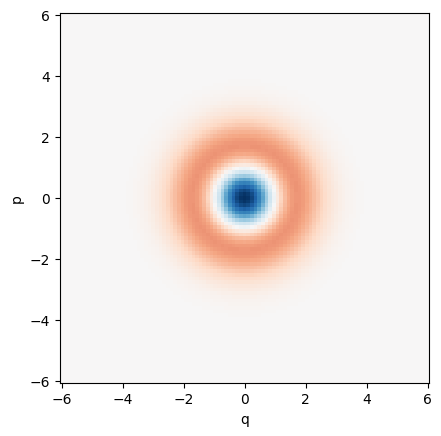

In [44]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

result = pg.simulate(
    pg.Pattern(inputs=(0,)), inputs={0: pg.FockInput.number(1)}, backend="piquasso-fock", cutoff=8
)
grid = result.state.wigner(np.linspace(-6, 6, 101), np.linspace(-6, 6, 101))
print("Captured mass:", grid.captured_mass)
print("Negative volume:", grid.negative_volume)
assert abs(grid.captured_mass - 1) < 1e-5
assert grid.negative_volume > 0.1
grid.plot()
plt.show()

**Interpretation.** A negative region near the origin is expected for an odd photon-number state. Finite-grid negativity is a numerical estimate dependent on window and spacing.

**Things to try.** Repeat with 51 and 151 points, then shrink the window. Identify integration error versus lost tails.

# Part III — Structure, extensibility and v0.3 paths

## 17. Graphix structural validation

**Goal.** Compare the same labelled resource edges and boundaries in Graphix. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Graphix describes qubit MBQC, so only the causal and graph skeleton is compared. Its state amplitudes cannot validate CV quadrature physics. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Matching edges: [(0, 1)]
Matching outputs: (1,)


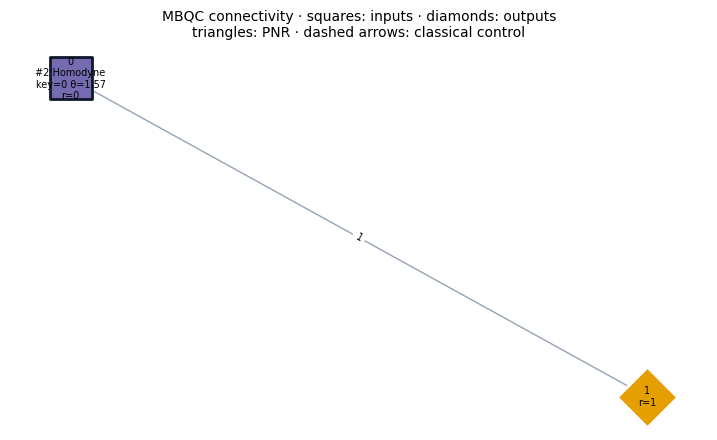

In [97]:
import graphix
import matplotlib.pyplot as plt
from graphix import command

import photographiq as pg

dv = graphix.Pattern(input_nodes=[0])
dv.add(command.N(1))
dv.add(command.E((0, 1)))
dv.add(command.M(0))
cv = pg.Pattern(pg.CVGraph.line(2, inputs=(0,))).measure(0, pg.Homodyne.p())


def edges(graph):
    return {frozenset(e) for e in graph.edges()}


assert edges(dv.to_opengraph().graph) == edges(cv.graph.network)
assert tuple(dv.output_nodes) == cv.outputs
print("Matching edges:", sorted(tuple(sorted(e)) for e in edges(cv.graph.network)))
print("Matching outputs:", cv.outputs)
cv.draw()
plt.show()

**Interpretation.** Matching graph structure checks labels and connectivity for this example. It says nothing about coherent amplitudes, photon probabilities or finite squeezing.

**Things to try.** Introduce nonconsecutive labels with an explicit bijection. Demonstrate why unlabeled graph isomorphism alone misses a swapped input.

## 18. Custom CV graph topology

**Goal.** Build a weighted graph with semantic node labels. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Weighted CZ couplings and per-node squeezing describe a resource independently of its drawing layout. Runtime labels can be arbitrary hashable objects. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Surviving labels: ('upper', 'lower')
Covariance shape: (4, 4)


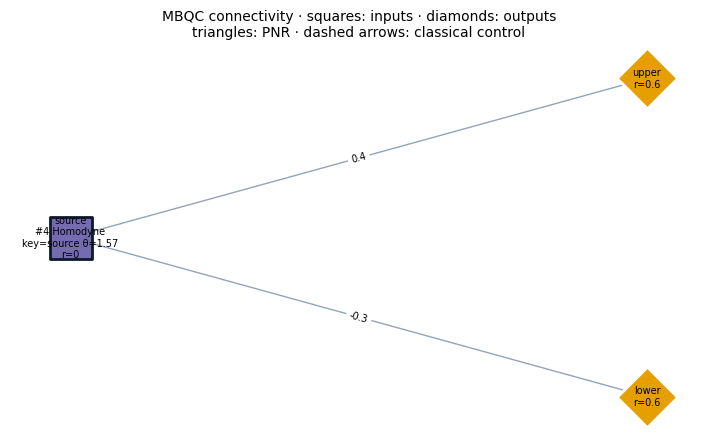

In [98]:
import matplotlib.pyplot as plt
import networkx as nx

import photographiq as pg

network = nx.Graph()
network.add_edge("source", "upper", weight=0.4)
network.add_edge("source", "lower", weight=-0.3)
graph = pg.CVGraph(network, squeezing=0.6, inputs=("source",))
pattern = pg.Pattern(graph).measure("source", pg.Homodyne.p())
result = pg.simulate(pattern, seed=7, backend="gaussian")
print("Surviving labels:", result.state.nodes)
print("Covariance shape:", result.state.covariance.shape)
assert set(result.state.nodes) == {"upper", "lower"}
pattern.draw(positions={"source": (0, 0), "upper": (1, 1), "lower": (1, -1)})
plt.show()

**Interpretation.** Labels identify physical/logical roles and persist through destructive measurement. The manual layout changes the figure, not the state preparation.

**Things to try.** Change one edge weight sign. Compare output correlations before rearranging the drawing coordinates.

## 19. Building a reusable Pattern

**Goal.** Bind one symbolic pattern repeatedly and round-trip its JSON description. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Parameter names are external scalars. Outcome expressions are runtime dependencies. Safe versioned JSON stores allowlisted descriptions, never arbitrary Python evaluation. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

k= -0.2 output q= (-0.0005667766880109561, 0.8277217759777526)
k= 0.0 output q= (-0.0005471294432225224, 0.8021838885585821)
k= 0.2 output q= (-0.0005667766880109561, 0.8277217759777526)


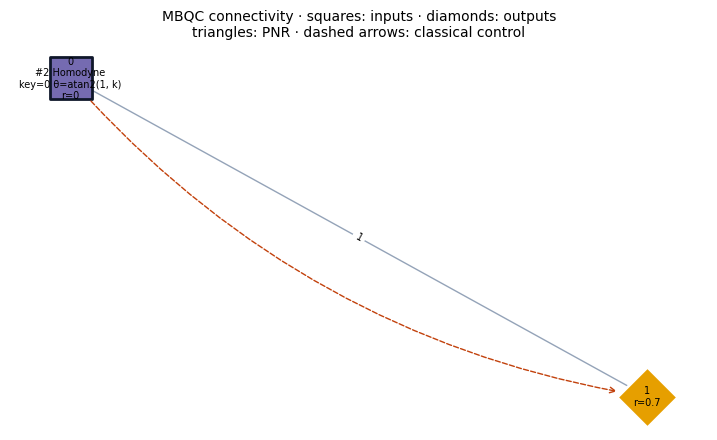

In [99]:
import matplotlib.pyplot as plt

import photographiq as pg

pattern = pg.protocols.wire([pg.Parameter("k")], squeezing=0.7)
restored = pg.Pattern.from_json(pattern.to_json())
for k in (-0.2, 0.0, 0.2):
    result = pg.simulate(restored, parameters={"k": k}, seed=7, backend="gaussian")
    print("k=", k, "output q=", result.state.quadrature(restored.outputs[0]))
assert restored.to_json() == pattern.to_json()
restored.draw()
plt.show()

**Interpretation.** The serialized object is the experiment description, not a simulated trajectory. Rebinding k changes the measurement pattern without editing its structure.

**Things to try.** Use independent seeds for repeated-shot estimates. Try serializing a CallableExpression and explain the deliberate rejection.

## 20. Circuit to MBQC compilation and visualization

**Goal.** Follow each source gate into resources, measurements and corrections. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** A correspondence diagram needs compiler provenance. Graph layout alone cannot reliably reconstruct which teleportation gadget came from a source gate. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Gate 0 R resources (1, 2, 3, 4) measurements (2, 6, 10, 14) corrections (3, 7, 11, 15)
Gate 1 S resources (5, 6, 7, 8, 9) measurements (18, 22, 26, 30, 34) corrections (19, 23, 27, 31, 35)


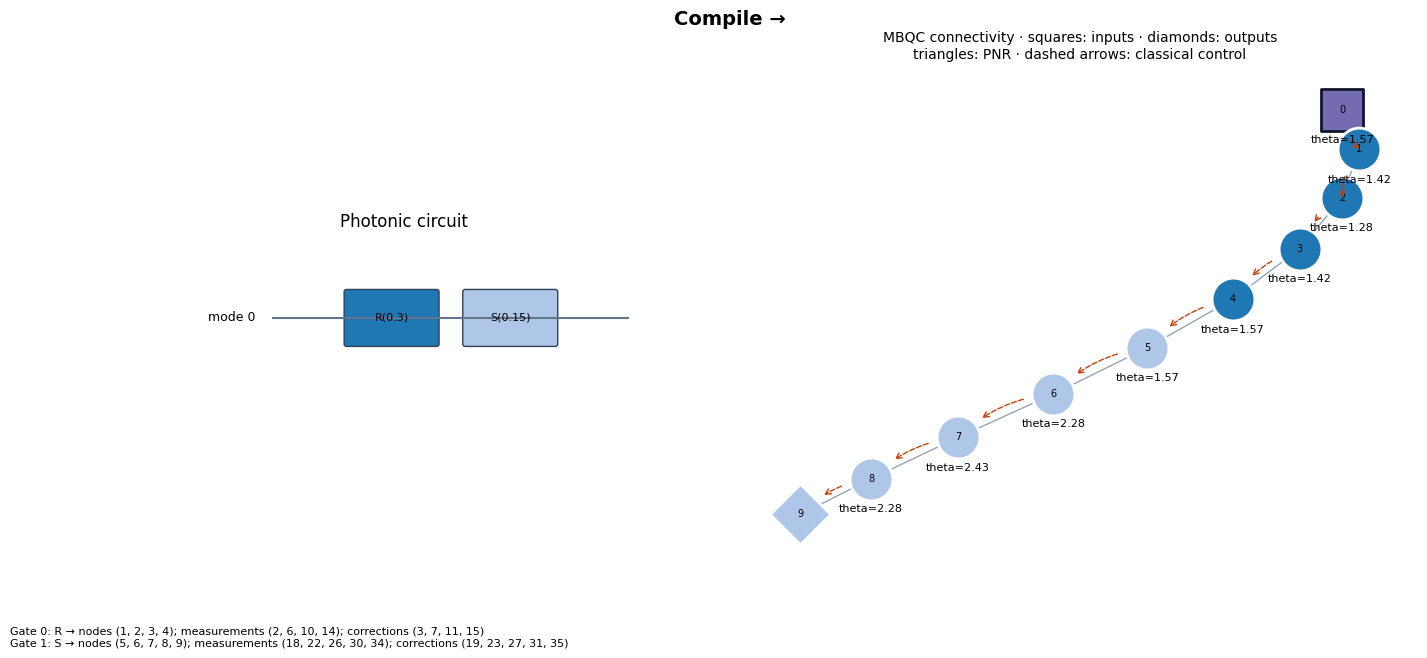

In [100]:
import matplotlib.pyplot as plt

import photographiq as pg

circuit = pg.Circuit(1).rotate(0, 0.3).squeeze(0, 0.15)
pattern, trace = circuit.compile(squeezing=0.8, return_trace=True)
for step in trace.steps:
    print(
        "Gate",
        step.gate_index,
        step.source_gate,
        "resources",
        step.resource_nodes,
        "measurements",
        step.measurements,
        "corrections",
        step.corrections,
    )
assert sum(len(step.measurements) for step in trace.steps) == sum(
    isinstance(c, pg.Measure) for c in pattern.commands
)
pg.visualize_compilation(circuit, pattern, trace=trace)
plt.show()

**Interpretation.** Color identifies generated resource ownership. Frontier nodes may be shared between consecutive gates; correction indices refer to the full temporal command list.

**Things to try.** Save SVG and PDF. Modify the pattern after compiling and verify that the correspondence view rejects the stale trace.

## 21. Mixed Fock evolution

**Goal.** Track a lossy nonlinear trajectory as a density matrix. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Loss destroys purity by entangling the field with an unobserved environment. A density matrix retains the unconditional mixture while allowing later conditional measurement. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Photon probabilities: {(np.int32(0),): np.float64(0.16000000000000003), (np.int32(1),): np.float64(0.48), (np.int32(2),): np.float64(0.36), (np.int32(3),): np.float64(0.0), (np.int32(4),): np.float64(0.0), (np.int32(5),): np.float64(0.0)}
Purity: 0.3856


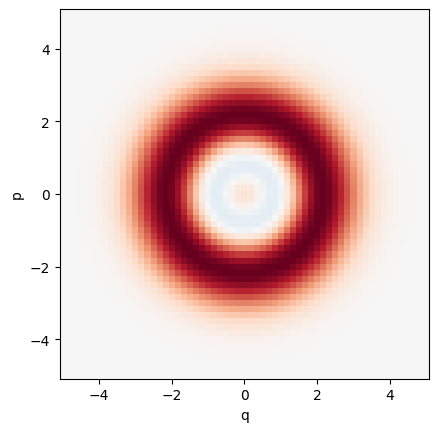

In [101]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

pattern = pg.Pattern(inputs=(0,)).append(pg.Kerr(0, 0.2)).append(pg.Loss(0, 0.6))
result = pg.simulate(
    pattern, inputs={0: pg.FockInput.number(2)}, backend="piquasso-mixed-fock", cutoff=6
)
rho = result.state.density_matrix
print("Photon probabilities:", result.state.probabilities)
print("Purity:", np.trace(rho @ rho).real)
assert np.isclose(result.state.photon_number(0), 1.2)
assert np.linalg.eigvalsh(rho).min() > -1e-12
result.state.wigner(np.linspace(-5, 5, 61), np.linspace(-5, 5, 61)).plot()
plt.show()

**Interpretation.** The density matrix is positive and trace one, but purity is below one. Kerr has no observable phase effect on the chosen number-state input; the mixture here comes from loss.

**Things to try.** Replace the input with a superposition to make Kerr phase observable. Compare thermal and vacuum environments.

## 22. Compiling a nonlinear resource injection

**Goal.** Compile a circuit-level cubic gate into an executable resource pattern. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Gaussian operations plus cubic phase form a universal CV gate set. A finite-energy implementation retains resource filtering; the polynomial front end currently accepts quadrature degrees up to four. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

/content/PhotoGraphiQ/src/photographiq/backends/fock.py:465: RuntimeWarning: GaussianTransform: retained Fock norm 0.99999999; test a larger cutoff
  self._gate((u, v), pq.GaussianTransform(passive=passive, active=active))


Generated commands: 8
Branch density: 0.25221987614730845


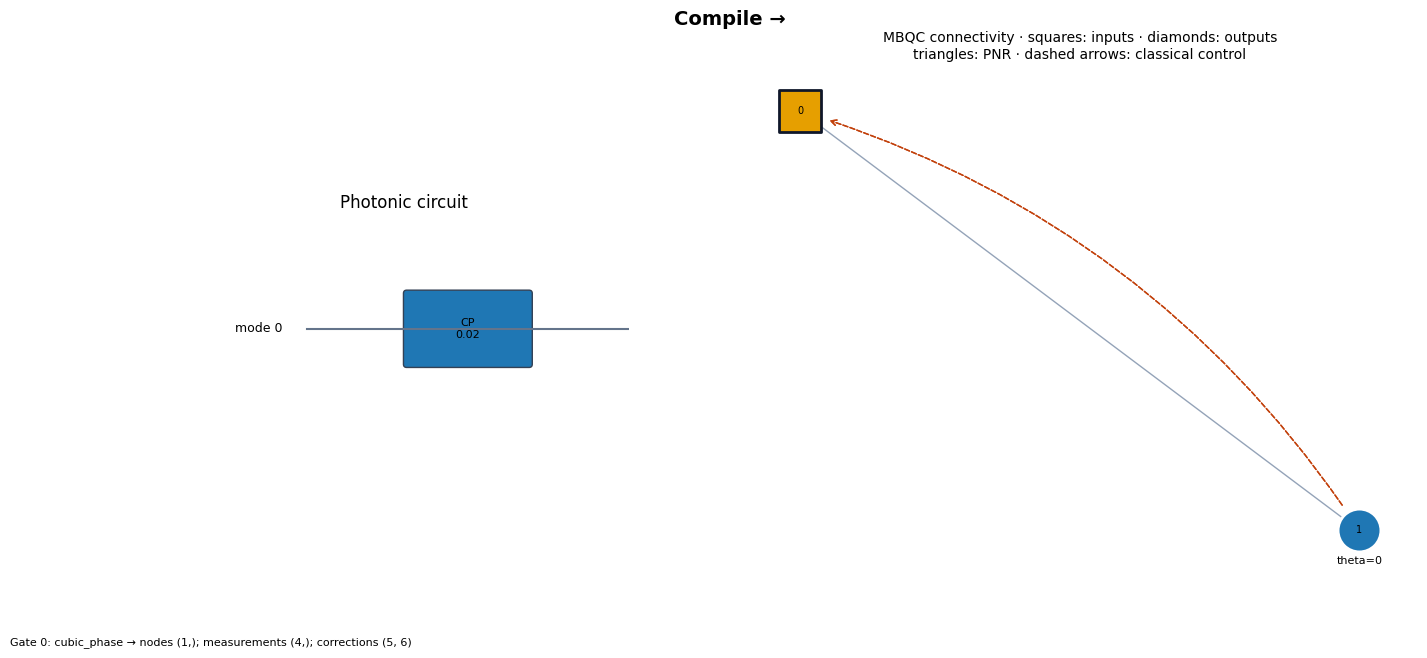

In [102]:
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

circuit = pg.Circuit(1).cubic_phase(0, 0.02)
pattern, trace = circuit.compile(squeezing=0.2, return_trace=True)
result = pg.simulate(
    pattern, backend="piquasso-fock", cutoff=24, measurement_outcomes={("cubic", 1): 0.1}
)
print("Generated commands:", len(pattern.commands))
print("Branch density:", np.exp(result.log_likelihood))
assert len(trace.steps[0].measurements) == 1
pg.visualize_compilation(circuit, pattern, trace=trace)
plt.show()

**Interpretation.** The cubic gate is supplied by a prepared nonlinear resource and Gaussian corrections. Its finite envelope remains part of the simulated result.

**Things to try.** Inspect a Kerr synthesis report at steps 1 and 4 before compiling it. Estimate resource cost and separate synthesis from injection errors.

## 23. Finite-energy GKP resources

**Goal.** Inspect grid projection and stabilizer expectations. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** Finite Gaussian combs approximate lattice code states. Peak width, envelope, finite lattice sum, numerical grid and Fock cutoff are distinct controls. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Captured Fock weight: 0.9999999999778135
Stabilizer expectations: {'q_translation': (0.3833993455900827+0j), 'p_translation': (0.45593812279977597-1.188899853156138e-17j)}
Decoded shifted cell: (0.10000000000000009, 1)


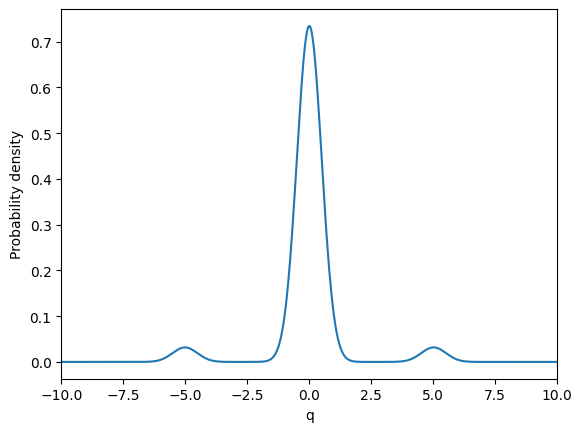

In [103]:
import matplotlib.pyplot as plt

import photographiq as pg

resource = pg.GKPResource(0, peak_width=0.5, envelope=0.5, peaks=4, grid_points=2049)
initial, mass = resource.project(48)
result = pg.simulate(
    pg.Pattern(inputs=(0,)), inputs={0: initial}, backend="piquasso-fock", cutoff=48
)
print("Captured Fock weight:", mass)
print("Stabilizer expectations:", pg.gkp.stabilizers(result.state))
print("Decoded shifted cell:", pg.gkp.decode_shift(pg.gkp.SPACING + 0.1))
assert mass > 0.99
q, psi = resource.wavefunction()
plt.plot(q, abs(psi) ** 2)
plt.xlim(-10, 10)
plt.xlabel("q")
plt.ylabel("Probability density")
plt.show()

**Interpretation.** Finite stabilizers do not equal one, and good Fock capture does not prove grid convergence. The decoder reports residual shift and logical cell parity.

**Things to try.** Refine peaks and grid separately. Build a logical-plus ancilla and inspect correction_pattern before a small fixed-syndrome simulation.

## 24. Automatic differentiation

**Goal.** Compare a JAX derivative with an analytical rotation derivative. Install the [required extras](../../docs/getting-started/installation.md) first.

**Theory.** A fixed-topology numerical program can propagate parameter derivatives. Measurement normalization and branch likelihood require distinct treatment; discrete sampling needs an estimator. All examples use [hbar=2 conventions](../../docs/getting-started/conventions.md).

Gradient: -0.2955202066613396
Analytical derivative: -0.29552020666133955


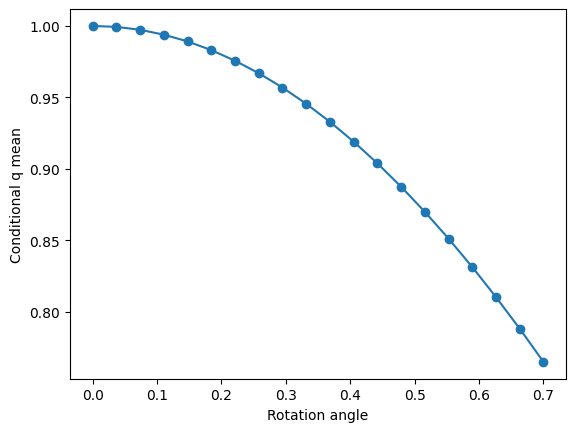

In [109]:
import jax
import matplotlib.pyplot as plt
import numpy as np

import photographiq as pg

jax.config.update("jax_enable_x64", True)
from photographiq import autodiff  # noqa: E402

pattern = pg.Pattern(inputs=(0,)).append(pg.Rotate(0, pg.Parameter("theta")))
initial = pg.FockInput((2**-0.5, 2**-0.5))


def objective(theta):
    return autodiff.expectation(
        pattern, {"theta": theta}, cutoff=6, inputs={0: initial}, observable="q"
    )

values = np.linspace(0.0, 0.7, 20)
gradient = float(jax.grad(objective)(0.3))
print("Gradient:", gradient)
print("Analytical derivative:", -np.sin(0.3))
assert abs(gradient + np.sin(0.3)) < 1e-10
plt.plot(values, [float(objective(t)) for t in values], marker="o")
plt.xlabel("Rotation angle")
plt.ylabel("Conditional q mean")
plt.show()

**Interpretation.** The derivative is of the finite-Fock expectation with respect to angle. Here it agrees with -sin(theta), independently of a stochastic estimator.

**Things to try.** Add vacuum loss with a trainable transmissivity. Compare selected-branch gradients with gradients of its probability.

# Part IV — Encoded GKP logic

These examples distinguish finite physical primitives from ideal logical targets.

The executable assertions check the stated identities or refusal behavior. Physical
readout uses the existing conditional Fock backend; independent reference tests are
described in the [validation guide](../../docs/validation/gkp-logical-validation.md).
Printed finite fidelities and error probabilities are observations, not universal bounds.

**Limitations.** All examples use finite, nonorthogonal codewords and exclusive total-photon cutoff.
They do not establish fault tolerance or full physical MuTA. Physical Y, pi/4 and
arbitrary XY remain unsupported. The [downstream contract](../../docs/development/photographiqml-contract.md)
states the precise supported interfaces and result meanings.

## 37. Finite-energy logical zero and one

**Goal.** Compare actual finite codewords without replacing them by an orthogonal basis.

**Theory.** The finite Gaussian comb has nonzero codeword overlap. Its Gram matrix controls normalization and the subspace projector.

In [110]:
import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

zero, one = code.zero(), code.one()
print("Gram matrix:", code.gram)
print("zero leakage:", code.leakage(zero.amplitudes))
print("one leakage:", code.leakage(one.amplitudes))
assert abs(code.gram[0, 1]) > 0
assert code.leakage(zero.amplitudes) < 1e-10
print("captured mass:", code.resource(0).project(code.cutoff)[1])

Gram matrix: [[1.        +0.j 0.12296524+0.j]
 [0.12296524+0.j 1.        +0.j]]
zero leakage: 0.0
one leakage: 1.1102230246251565e-16
captured mass: 0.9999999999999998


**Convergence.** Repeat with larger cutoff, grid_points and peaks independently. Overlap need not tend to zero when only numerical resolution changes.

## 38. Logical Z from q homodyne

**Goal.** Obtain an analog Z record and its modular parity.

**Theory.** Ideal q peaks lie at mL; cell parity is the logical Z label. Finite peaks have a nonzero tail across cell boundaries.

In [111]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

p = pg.Pattern(inputs=(0,)).measure(0, code.logical_measurement("Z"), key="z")
r = pg.simulate(
    p,
    inputs={0: code.zero()},
    backend="piquasso-fock",
    cutoff=code.cutoff,
    measurement_outcomes={"z": 0.25},
)
print(r.outcomes["z"])
print(r.measurement_statistics)
assert r.outcomes["z"].bit == 0
assert r.outcomes["z"].raw_outcome == 0.25
v = np.array(code.zero().amplitudes)
print(
    "integrated Z probabilities:",
    np.einsum("i,kij,j->k", v.conj(), pg.modular_effects(code.cutoff), v).real,
)

LogicalDecodeResult(bit=0, raw_outcome=0.25, cell=0, residual=0.25, decoder='nearest-cell', confidence=None, probabilities=None, code_subspace_leakage=None, frame_correction=0)
{'z': {'kind': 'density', 'value': 0.6020995319145024, 'postselected': True}}
integrated Z probabilities: [0.97729564 0.02270436]


**Convergence.** Compare integrated probabilities with measurement_convergence at cutoffs 24,48,80. A fixed analog branch tests conditioning, not statistical accuracy.

## 39. Logical X from p homodyne

**Goal.** Read the finite plus state using momentum homodyne.

**Theory.** The hbar=2 Fourier transform maps ideal plus/minus to even/odd momentum cells. Logical X is p homodyne, not q homodyne.

In [112]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

p = pg.Pattern(inputs=(0,)).measure(0, code.logical_measurement("X"), key="x")
r = pg.simulate(
    p,
    inputs={0: code.plus()},
    backend="piquasso-fock",
    cutoff=code.cutoff,
    measurement_outcomes={"x": -0.2},
)
print(r.outcomes["x"])
assert r.outcomes["x"].bit == 0
for state in (code.plus(), code.minus()):
    v = np.array(state.amplitudes)
    print(np.einsum("i,kij,j->k", v.conj(), pg.modular_effects(code.cutoff, "X"), v).real)

LogicalDecodeResult(bit=0, raw_outcome=-0.2, cell=0, residual=-0.2, decoder='nearest-cell', confidence=None, probabilities=None, code_subspace_leakage=None, frame_correction=0)
[0.99107744 0.00892256]
[0.01220681 0.98779319]


**Convergence.** Sweep cutoff and resource envelope separately. The continuous-comb Fourier oracle in the tests establishes finite readout probabilities.

## 40. Soft GKP decoding

**Goal.** Compare parity decisions with ensemble posteriors.

**Theory.** Bayes conditioning uses the two specified finite preparation densities. It is not normalization of overlaps with an unknown logical state.

In [113]:
import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

decoder = pg.SoftDecisionDecoder(code, "Z")
for raw in (-2.6, 0.1, 1.2, 2.6):
    result = decoder.decode(raw)
    print(result)
    assert abs(sum(result.probabilities) - 1) < 1e-12
    assert result.confidence == max(result.probabilities)
print("nearest-cell:", code.decode(1.2))

LogicalDecodeResult(bit=1, raw_outcome=-2.6, cell=-1, residual=-0.09337172536899985, decoder='finite-fock-ensemble-bayes', confidence=0.9999447181406281, probabilities=(np.float64(5.528185937180216e-05), np.float64(0.9999447181406281)), code_subspace_leakage=None, frame_correction=0)
LogicalDecodeResult(bit=0, raw_outcome=0.1, cell=0, residual=0.1, decoder='finite-fock-ensemble-bayes', confidence=0.9999208664586718, probabilities=(np.float64(0.9999208664586718), np.float64(7.913354132827791e-05)), code_subspace_leakage=None, frame_correction=0)
LogicalDecodeResult(bit=0, raw_outcome=1.2, cell=0, residual=1.2, decoder='finite-fock-ensemble-bayes', confidence=0.7415066713790178, probabilities=(np.float64(0.7415066713790178), np.float64(0.25849332862098223)), code_subspace_leakage=None, frame_correction=0)
LogicalDecodeResult(bit=1, raw_outcome=2.6, cell=1, residual=0.09337172536899985, decoder='finite-fock-ensemble-bayes', confidence=0.9999447181406281, probabilities=(np.float64(5.528185

**Convergence.** Recompute likelihoods at larger cutoff. Calibration tests use synthetic draws from an independent continuous-comb ensemble.

## 41. Logical X and Z displacements

**Goal.** Measure finite target distortion under lattice displacements.

**Theory.** X shifts q by L and Z shifts p by L. Their actions include translating the finite envelope; ideal Pauli identities do not imply unit finite-code fidelity.

In [114]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

for gate in ("X", "Z"):
    source = code.zero() if gate == "X" else code.plus()
    target = code.one() if gate == "X" else code.minus()
    p = pg.Pattern(inputs=(0,)).append(code.logical_gate(0, gate))
    r = pg.simulate(p, inputs={0: source}, backend="piquasso-fock", cutoff=code.cutoff)
    fidelity = abs(np.vdot(target.amplitudes, r.state.state_vector)) ** 2
    print(gate, "target fidelity:", fidelity, "leakage:", code.leakage(r.state.state_vector))
    assert 0 < fidelity < 1

X target fidelity: 0.6803065023617856 leakage: 0.3196905641474561
Z target fidelity: 0.6312556883445124 leakage: 0.3687443116080644


**Convergence.** Compare cutoffs 48,80,112. Physical envelope error can remain even when numerical fidelity changes stop.

## 42. GKP Hadamard

**Goal.** Compare the Fourier-rotated zero with the finite plus target.

**Theory.** A pi/2 oscillator rotation realizes logical H on the ideal square lattice. A finite comb need not be self-dual under the Fourier transform.

In [115]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

p = pg.Pattern(inputs=(0,)).append(code.logical_gate(0, "H"))
r = pg.simulate(p, inputs={0: code.zero()}, backend="piquasso-fock", cutoff=code.cutoff)
fidelity = abs(np.vdot(code.plus().amplitudes, r.state.state_vector)) ** 2
print("H target fidelity:", fidelity)
print(code.diagnostics(r.state))
assert 0 < fidelity <= 1 + 1e-12

H target fidelity: 0.9778057387749954
{'gram': array([[1.        +0.j, 0.12296524+0.j],
       [0.12296524+0.j, 1.        +0.j]]), 'code_subspace_leakage': 0.017373747114249438, 'stabilizers': {'q_translation': (0.38661273268620905-3.639396819163585e-17j), 'p_translation': (0.3834198721649713-4.92356337814373e-32j)}}


**Convergence.** H itself preserves Fock occupation. Resource convergence and finite target mismatch still require checks.

## 43. GKP phase gate

**Goal.** Inspect the physical shear that realizes ideal-lattice S.

**Theory.** At q=mL, exp(iq^2/4) is 1 on even m and i on odd m. Within a finite peak this phase varies continuously and distorts the wavefunction.

In [116]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

p = pg.Pattern(inputs=(0,)).append(code.logical_gate(0, "S"))
r = pg.simulate(p, inputs={0: code.plus()}, backend="piquasso-fock", cutoff=code.cutoff)
target = code.encode(1, 1j)
fidelity = abs(np.vdot(target.amplitudes, r.state.state_vector)) ** 2
print("S target fidelity:", fidelity)
print(code.diagnostics(r.state))
assert 0 < fidelity < 1

/content/PhotoGraphiQ/src/photographiq/backends/fock.py:519: RuntimeWarning: QuadraticPhase: retained Fock norm 0.99999996; test a larger cutoff
  self._gate((node,), pq.QuadraticPhase(s=s))


S target fidelity: 0.7552045770199184
{'gram': array([[1.        +0.j, 0.12296524+0.j],
       [0.12296524+0.j, 1.        +0.j]]), 'code_subspace_leakage': 0.23418646948183464, 'stabilizers': {'q_translation': (0.13377149243941486-5.4969050145015075e-17j), 'p_translation': (0.30194500945796954+3.507394027990607e-17j)}}


**Convergence.** The shear populates higher Fock levels. Compare output fidelity and stabilizers at increasing cutoff; norm conservation is insufficient.

## 44. Two-mode logical CZ

**Goal.** Execute a finite two-mode encoded CZ and inspect correlated readout.

**Theory.** At ideal sites exp(i q1 q2/2)=(-1)^(mn). Total photon truncation couples the represented support of both modes.

In [117]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

v = np.array(code.plus().amplitudes)
data = {(i, j): v[i] * v[j] for i in range(code.cutoff) for j in range(code.cutoff - i)}
mass = sum(abs(a) ** 2 for a in data.values())
source = pg.FockSuperposition.from_mapping({k: a / np.sqrt(mass) for k, a in data.items()})
p = pg.Pattern(inputs=(0, 1)).append(code.logical_cz(0, 1))
r = pg.simulate(p, initial_state=source, backend="piquasso-fock", cutoff=code.cutoff)
print("total preparation mass:", mass)
probabilities = pg.multimode_readout(r.state, {0: "X", 1: "Z"})
print(probabilities)
assert abs(sum(probabilities["joint_probabilities"].values()) - 1) < 1e-9

/content/PhotoGraphiQ/src/photographiq/backends/fock.py:465: RuntimeWarning: GaussianTransform: retained Fock norm 0.99999979; test a larger cutoff
  self._gate((u, v), pq.GaussianTransform(passive=passive, active=active))


total preparation mass: 0.9999999999999962
{'joint_probabilities': {(0, 0): 0.4513677293270218, (0, 1): 0.048635880786911743, (1, 0): 0.048636474583496875, (1, 1): 0.45135991530256714}, 'marginal_probabilities': {0: (0.5000036101139336, 0.499996389886064), 1: (0.5000042039105187, 0.49999579608947886)}, 'frames': {}, 'code_subspace_leakage': None, 'residuals': None, 'decoder': 'nearest-cell'}


**Convergence.** Run the independent CZ evidence at total cutoffs 24,40,64. Joint probabilities must be compared directly; multiplying marginals loses correlations.

## 45. Logical Pauli frames

**Goal.** Propagate ideal binary byproducts and resolve readout labels.

**Theory.** Conjugation by X^x Z^z changes an XY angle to (-1)^x alpha+pi*z. H swaps frame bits and S maps z to z xor x.

In [ ]:
import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

frame = pg.LogicalPauliFrame(1, 0)
print("H:", frame.hadamard(), "S:", frame.phase())
print("CZ:", frame.cz(pg.LogicalPauliFrame(0, 1)))
print("adapted angle:", frame.xy_angle(0.3))
p = pg.Pattern(inputs=(0,)).measure(0, pg.PhysicalGKPReadout("Z", frame=frame), key="m")
p.append(pg.Signal("bit", pg.CallableExpression(lambda r: r["m"].bit, frozenset({"m"}))))
r = pg.simulate(
    p,
    inputs={0: code.zero()},
    backend="piquasso-fock",
    cutoff=code.cutoff,
    measurement_outcomes={"m": 0.1},
)
print(r.records)
assert r.records["bit"] == 1

**Convergence.** Frame algebra is exact on ideal qubits and tested independently. It is not a claim that finite envelope corrections can always be deferred exactly.

## 46. Encoded finite measurement instrument

**Goal.** Distinguish ambiguity from outside-code leakage.

**Theory.** Reciprocal code vectors produce unambiguous conclusive effects. A separate inconclusive effect completes the resolution within the code span.

In [ ]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

instrument = code.discrimination_instrument()
probabilities = instrument.probabilities(code.zero().amplitudes)
print(probabilities)
assert abs(probabilities[1]) < 1e-10
assert probabilities["inconclusive"] > 0
assert abs(probabilities["outside-code"]) < 1e-10
p, rho = instrument.conditional(code.zero().amplitudes, 0)
print("branch probability:", p, "trace:", np.trace(rho))
assert abs(np.trace(rho) - 1) < 1e-10

**Convergence.** Compare the Gram eigenvalues with refined resource parameters. This is a mathematical instrument and has no supplied optical synthesis.

## 47. The pi/4 measurement boundary

**Goal.** Verify that ideal pi/4 probabilities do not enable physical injection.

**Theory.** An arbitrary logical Rz rotation requires a validated encoded protocol. Rotated optical homodyne is not a substitute for a logical XY measurement.

In [ ]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

alpha = np.pi / 4
print("ideal qubit probabilities:", pg.IdealLogicalXYMeasurement(alpha).probabilities([1, 0]))
try:
    code.logical_measurement("XY", alpha=alpha)
except NotImplementedError as error:
    print("physical request refused:", error)
else:
    raise AssertionError("Unvalidated physical pi/4 readout must be refused")

**Convergence.** There is no physical convergence claim for this unsupported operation. Injection needs a literature-backed complete branch protocol before validation can begin.

## 48. Independent GKP convergence axes

**Goal.** Inspect probability and residual convergence rather than captured mass alone.

**Theory.** Cutoff changes the represented Hilbert space; grid and peaks change resource quadrature accuracy. Width and envelope change the physical resource.

In [ ]:
import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

study = pg.measurement_convergence(code, (24, 48), basis="X", coefficients=(1, -1))
for row in study.rows:
    print(row)
assert study.rows[-1]["fidelity_to_previous"] > 0.99
print("Two-mode study: python -m experiments.gkp_logical_evidence")

**Convergence.** The two-mode evidence includes joint readout, finite target fidelity, subspace leakage and stabilizers. A small state-preparation sweep cannot certify a large graph.

## 49. Preparing a downstream physical measurement step

**Goal.** Use encoded primitives through the public Pattern API.

**Theory.** The downstream package requests a logical basis. PhotoGraphiQ supplies its bosonic realization, analog record and explicit capability boundary.

In [ ]:
import numpy as np

import photographiq as pg

code = pg.GKPCode(peak_width=0.55, envelope=0.5, cutoff=80, peaks=6, grid_points=2049)

measurement = code.logical_measurement("XY", alpha=np.pi)
p = pg.Pattern(inputs=(0,)).measure(0, measurement, key="logical")
r = pg.simulate(
    p,
    inputs={0: code.plus()},
    backend="piquasso-fock",
    cutoff=code.cutoff,
    measurement_outcomes={"logical": 0.1},
)
print(r.outcomes["logical"])
assert r.outcomes["logical"].bit == 1
print("One signed-X step only. Full physical MuTA remains unsupported.")

**Convergence.** The cross-mode regression validates an X step after physical CZ. Downstream adaptive scheduling, output policy and full-circuit convergence are still required.